# Atividade 1 — Preparação e Análise de Dados para Redes Neurais

Solução dos três exercícios propostos em [1. Data](https://insper.github.io/ann-dl/2026.2/exercises/data/).

**Autoria e uso de IA.** Este relatório foi desenvolvido com colaboração do Codex (OpenAI). Para auxiliar no desenvolvimento dos códigos.



In [1]:
from pathlib import Path
from itertools import combinations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_rows", 30)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

# Uma única fonte de aleatoriedade para todo o relatório.
rng = np.random.default_rng(42)

# Exercício 1 — Nuvens de pontos: geometria e dispersão em 2D

## A — Geração das nuvens

Cada classe tem 100 observações. As coordenadas são independentes e seguem gaussianas com as médias e os desvios-padrão indicados no enunciado.

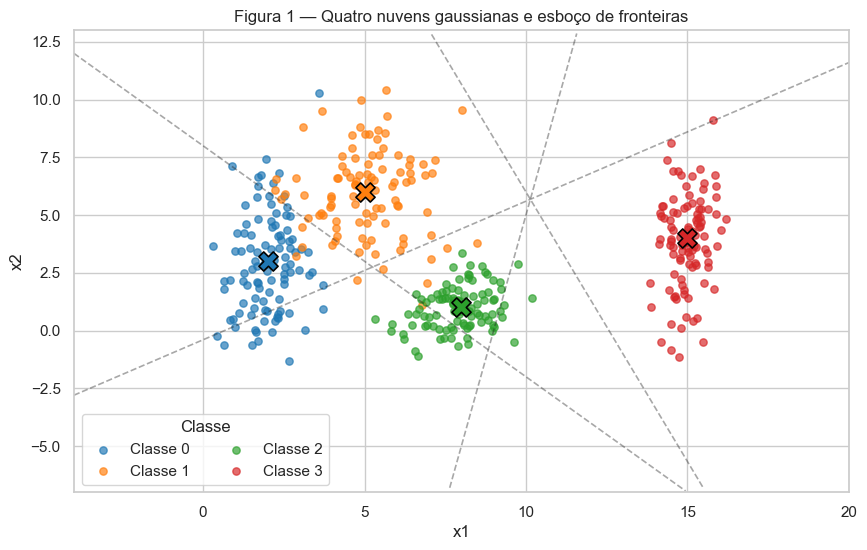

In [2]:
means = np.array([[2, 3], [5, 6], [8, 1], [15, 4]], dtype=float)
stds = np.array([[0.8, 2.5], [1.2, 1.9], [0.9, 0.9], [0.5, 2.0]], dtype=float)
n_per_class = 100

def generate_clouds(scale=1.0):
    # Gera as quatro classes usando o mesmo rng global.
    blocks = [rng.normal(loc=means[k], scale=stds[k] * scale,
                         size=(n_per_class, 2)) for k in range(4)]
    X = np.vstack(blocks)
    y = np.repeat(np.arange(4), n_per_class)
    return X, y

X1, y1 = generate_clouds(scale=1.0)

fig, ax = plt.subplots(figsize=(10, 6))
colors = sns.color_palette("tab10", 4)
for k, color in enumerate(colors):
    pts = X1[y1 == k]
    ax.scatter(pts[:, 0], pts[:, 1], s=28, alpha=0.68, color=color,
               label=f"Classe {k}")
    ax.scatter(*means[k], marker="X", s=190, color=color,
               edgecolor="black", linewidth=1.2)

# Esboço de fronteiras: mediatrizes entre centros vizinhos (regra do centro mais próximo).
xlim = (-4, 20)
ylim = (-7, 13)
for i, j in [(0, 1), (1, 2), (2, 3), (1, 3)]:
    delta = means[j] - means[i]
    midpoint = (means[i] + means[j]) / 2
    xs = np.linspace(*xlim, 300)
    if abs(delta[1]) > 1e-12:
        ys = midpoint[1] - delta[0] * (xs - midpoint[0]) / delta[1]
        mask = (ys >= ylim[0]) & (ys <= ylim[1])
        ax.plot(xs[mask], ys[mask], "k--", alpha=0.38, lw=1.2)

ax.set(xlim=xlim, ylim=ylim, xlabel="x1", ylabel="x2",
       title="Figura 1 — Quatro nuvens gaussianas e esboço de fronteiras")
ax.legend(title="Classe", ncol=2)
plt.show()

As linhas tracejadas são um **esboço**, não o resultado de um treinamento: são trechos das mediatrizes entre centros próximos. Elas representam regiões lineares por partes semelhantes às que uma rede poderia combinar para atribuir cada região do plano a uma classe.

## B — Mais ou menos dispersas

As médias permanecem fixas e todos os desvios-padrão são multiplicados por $s$. Cada painel abaixo é um conjunto de dados independente com quatro classes.

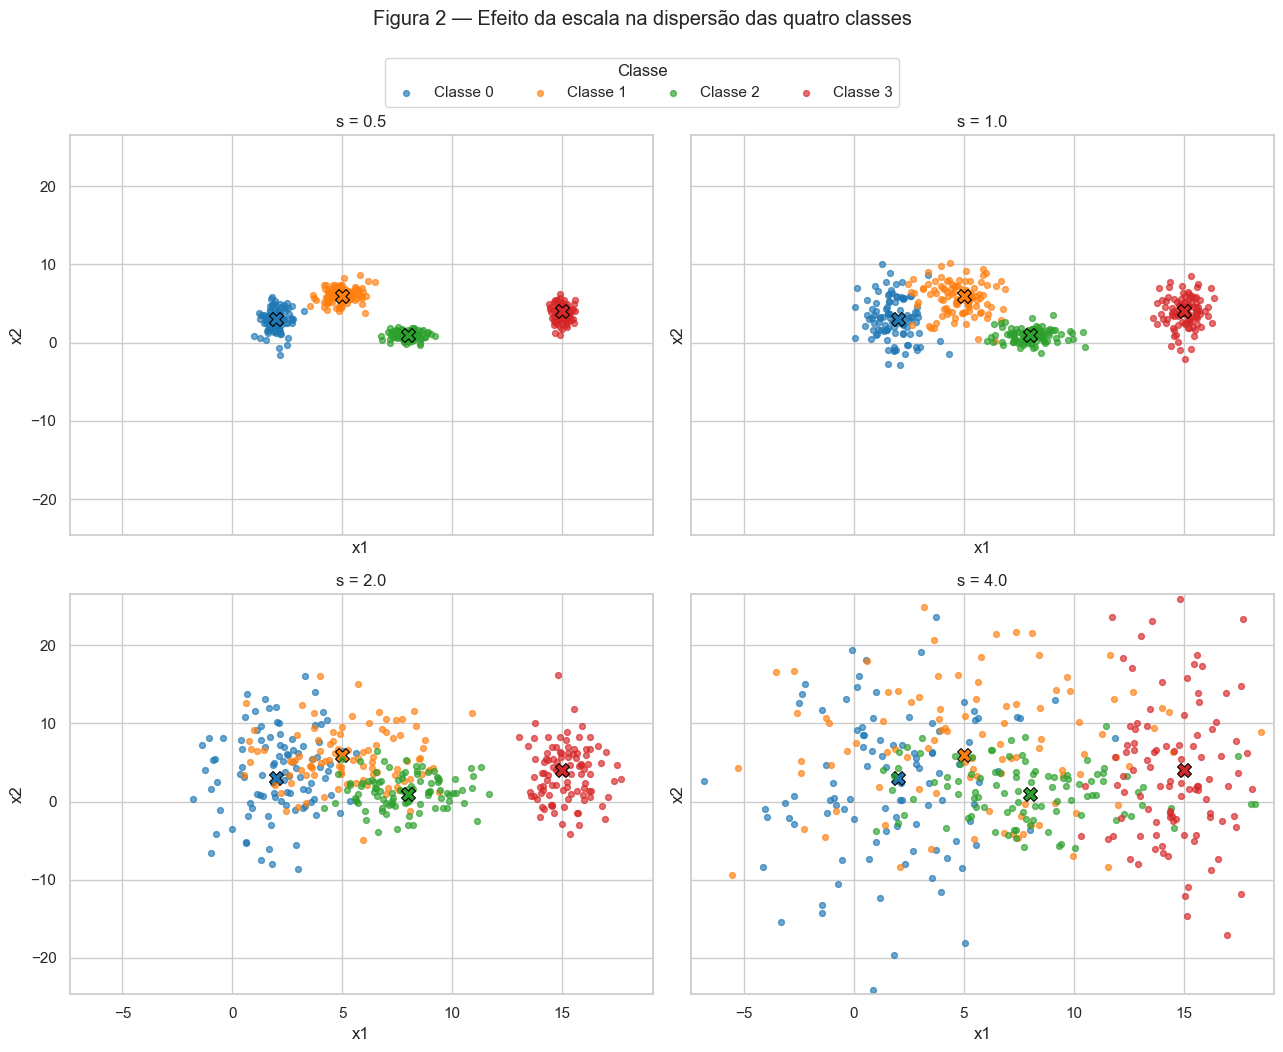

In [3]:
scales = [0.5, 1.0, 2.0, 4.0]
datasets_s = {s: generate_clouds(scale=s) for s in scales}

# Limites globais: exatamente os mesmos nos quatro painéis.
all_X = np.vstack([datasets_s[s][0] for s in scales])
pad = 0.6
shared_xlim = (all_X[:, 0].min() - pad, all_X[:, 0].max() + pad)
shared_ylim = (all_X[:, 1].min() - pad, all_X[:, 1].max() + pad)

fig, axes = plt.subplots(2, 2, figsize=(13, 10), sharex=True, sharey=True)
for ax, s in zip(axes.flat, scales):
    Xs, ys = datasets_s[s]
    for k, color in enumerate(colors):
        pts = Xs[ys == k]
        ax.scatter(pts[:, 0], pts[:, 1], s=18, alpha=0.65,
                   color=color, label=f"Classe {k}")
        ax.scatter(*means[k], marker="X", s=100, color=color,
                   edgecolor="black", linewidth=0.8)
        ax.set(title=f"s = {s}", xlabel="x1", ylabel="x2",
           xlim=shared_xlim, ylim=shared_ylim)

handles, labels = axes.flat[0].get_legend_handles_labels()
fig.legend(handles[:4], labels[:4], title="Classe", loc="upper center",
           ncol=4, bbox_to_anchor=(0.5, 1.01))
fig.suptitle("Figura 2 — Efeito da escala na dispersão das quatro classes", y=1.05)
fig.tight_layout()
plt.show()

In [4]:
# Razões de separação teóricas para s=1.
rows = []
mean_std = stds.mean(axis=1)
for i, j in combinations(range(4), 2):
    distance = np.linalg.norm(means[i] - means[j])
    ratio = distance / (mean_std[i] + mean_std[j])
    rows.append({"Par": f"({i}, {j})", "Distância entre médias": distance,
                 "r_ij (s=1)": ratio})

ratio_table = pd.DataFrame(rows).sort_values("r_ij (s=1)").reset_index(drop=True)
display(ratio_table.style.format({"Distância entre médias": "{:.4f}", "r_ij (s=1)": "{:.4f}"}))

smallest_pair = ratio_table.loc[0, "Par"]
smallest_ratio = ratio_table.loc[0, "r_ij (s=1)"]
display(Markdown(
    f"A menor razão em $s=1$ é **{smallest_ratio:.4f}**, para o par **{smallest_pair}**. "
    f"Como $r_{{ij}}$ varia com $1/s$, em $s=2$ ela se torna "
    f"**{smallest_ratio / 2:.4f}**, sem necessidade de gerar novos pontos."
))

,Par,Distância entre médias,r_ij (s=1)
0,"(0, 1)",4.2426,1.3258
1,"(1, 2)",5.8310,2.3800
2,"(0, 2)",6.3246,2.4802
3,"(2, 3)",7.6158,3.5422
4,"(1, 3)",10.1980,3.6422
5,"(0, 3)",13.0384,4.4960


A menor razão em $s=1$ é **1.3258**, para o par **(0, 1)**. Como $r_{ij}$ varia com $1/s$, em $s=2$ ela se torna **0.6629**, sem necessidade de gerar novos pontos.

,s,Taxa de mistura,Taxa de mistura (%)
0,0.500000,0.0000,0.00%
1,1.000000,0.0675,6.75%
2,2.000000,0.2250,22.50%
3,4.000000,0.4175,41.75%


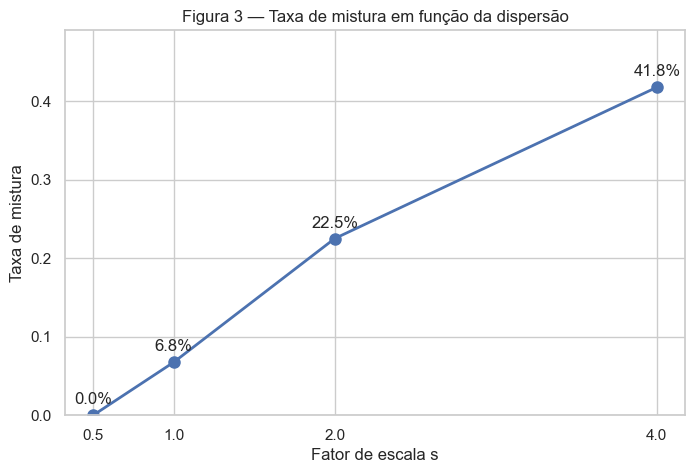

In [5]:
def mixing_rate(X, y):
    # Fração cujo centro mais próximo não é o centro da própria classe.
    sq_dist = ((X[:, None, :] - means[None, :, :]) ** 2).sum(axis=2)
    nearest_center = sq_dist.argmin(axis=1)
    return np.mean(nearest_center != y)

mixing = {s: mixing_rate(*datasets_s[s]) for s in scales}
mixing_table = pd.DataFrame({
    "s": scales,
    "Taxa de mistura": [mixing[s] for s in scales],
    "Taxa de mistura (%)": [100 * mixing[s] for s in scales],
})
display(mixing_table.style.format({"Taxa de mistura": "{:.4f}", "Taxa de mistura (%)": "{:.2f}%"}))

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(scales, [mixing[s] for s in scales], marker="o", ms=8, lw=2)
for s in scales:
    ax.annotate(f"{mixing[s]:.1%}", (s, mixing[s]), xytext=(0, 8),
                textcoords="offset points", ha="center")
ax.set(xlabel="Fator de escala s", ylabel="Taxa de mistura",
       title="Figura 3 — Taxa de mistura em função da dispersão",
       xticks=scales, ylim=(0, max(mixing.values()) * 1.15 + 0.01))
plt.show()

In [6]:
# Diagnóstico empírico: a partir do primeiro s em que existe mistura relevante.
first_mixed_scale = next(s for s in scales if mixing[s] > 0)
display(Markdown(
    f"Nos dados gerados, a taxa de mistura já é diferente de zero em "
    f"**s = {first_mixed_scale:g}** ({mixing[first_mixed_scale]:.2%}). "
    f"Porém, a perda visual clara da separação por regiões lineares ocorre a partir de "
    f"**s = 2**, quando a menor razão de separação cai para "
    f"**{smallest_ratio/2:.4f}**. Em $s=4$, a mistura se torna ainda mais intensa."
))

Nos dados gerados, a taxa de mistura já é diferente de zero em **s = 1** (6.75%). Porém, a perda visual clara da separação por regiões lineares ocorre a partir de **s = 2**, quando a menor razão de separação cai para **0.6629**. Em $s=4$, a mistura se torna ainda mais intensa.

## C — Análise

1. Em $s=1$, as classes 0 e 1 são as que mais se sobrepõem; também há alguma aproximação entre 1 e 2. **Uma única reta não separa quatro classes**, pois uma reta produz apenas dois semiplanos. Um conjunto de fronteiras lineares (por exemplo, uma regra multiclasse por centro mais próximo) consegue dividir grande parte do plano, mas os pontos nas caudas sobrepostas são inevitavelmente ambíguos e não podem ser todos separados sem erro por fronteiras simples.

2. A Figura 1 inclui o esboço pedido: as mediatrizes tracejadas particionam o plano em regiões associadas aos centros. Uma rede poderia aprender uma versão deslocada e linear por partes dessas fronteiras, adaptando-a às densidades observadas.

3. Quando $s$ aumenta, as caudas das classes passam a ocupar as mesmas regiões. A faixa em torno das fronteiras cresce e, com ela, cresce a região em que até uma boa rede necessariamente cometerá erros: entradas muito parecidas passam a ter rótulos diferentes. Isso é coerente com a queda de $r_{ij}$ e com o aumento da taxa de mistura.

# Exercício 2 — Não linearidade em dimensões maiores

## A — Dataset I: gaussianas deslocadas

São geradas 500 amostras por classe em cinco dimensões com as médias e matrizes de covariância especificadas.

In [7]:
mu_A = np.zeros(5)
mu_B = np.full(5, 1.5)
Sigma_A = np.array([
    [1.0, 0.8, 0.1, 0.0, 0.0],
    [0.8, 1.0, 0.3, 0.0, 0.0],
    [0.1, 0.3, 1.0, 0.5, 0.0],
    [0.0, 0.0, 0.5, 1.0, 0.2],
    [0.0, 0.0, 0.0, 0.2, 1.0],
])
Sigma_B = np.array([
    [1.5, -0.7, 0.2, 0.0, 0.0],
    [-0.7, 1.5, 0.4, 0.0, 0.0],
    [0.2, 0.4, 1.5, 0.6, 0.0],
    [0.0, 0.0, 0.6, 1.5, 0.3],
    [0.0, 0.0, 0.0, 0.3, 1.5],
])

XA = rng.multivariate_normal(mu_A, Sigma_A, size=500)
XB = rng.multivariate_normal(mu_B, Sigma_B, size=500)
X_gauss = np.vstack([XA, XB])
y_gauss = np.repeat(["A", "B"], 500)
print("Dataset I:", X_gauss.shape, "— 500 amostras em cada classe")

Dataset I: (1000, 5) — 500 amostras em cada classe


## B — Dataset II: cascas concêntricas

As direções são gaussianas normalizadas para a esfera unitária de $\mathbb{R}^5$. O raio da classe C se concentra em 2 e o da classe D em 5.

In [8]:
def shell_points(n, radius_mean, radius_std=0.4):
    v = rng.normal(size=(n, 5))
    u = v / np.linalg.norm(v, axis=1, keepdims=True)
    rho = rng.normal(radius_mean, radius_std, size=n)
    return u * rho[:, None]

XC = shell_points(500, 2.0)
XD = shell_points(500, 5.0)
X_shell = np.vstack([XC, XD])
y_shell = np.repeat(["C", "D"], 500)
print("Dataset II:", X_shell.shape, "— 500 amostras em cada classe")

Dataset II: (1000, 5) — 500 amostras em cada classe


## C — Visualização e comparação

Cada PCA é ajustado separadamente ao respectivo conjunto completo, sem usar os rótulos. A soma da variância explicada por PC1 e PC2 mede quanta variabilidade total foi retida, não a qualidade de um classificador.

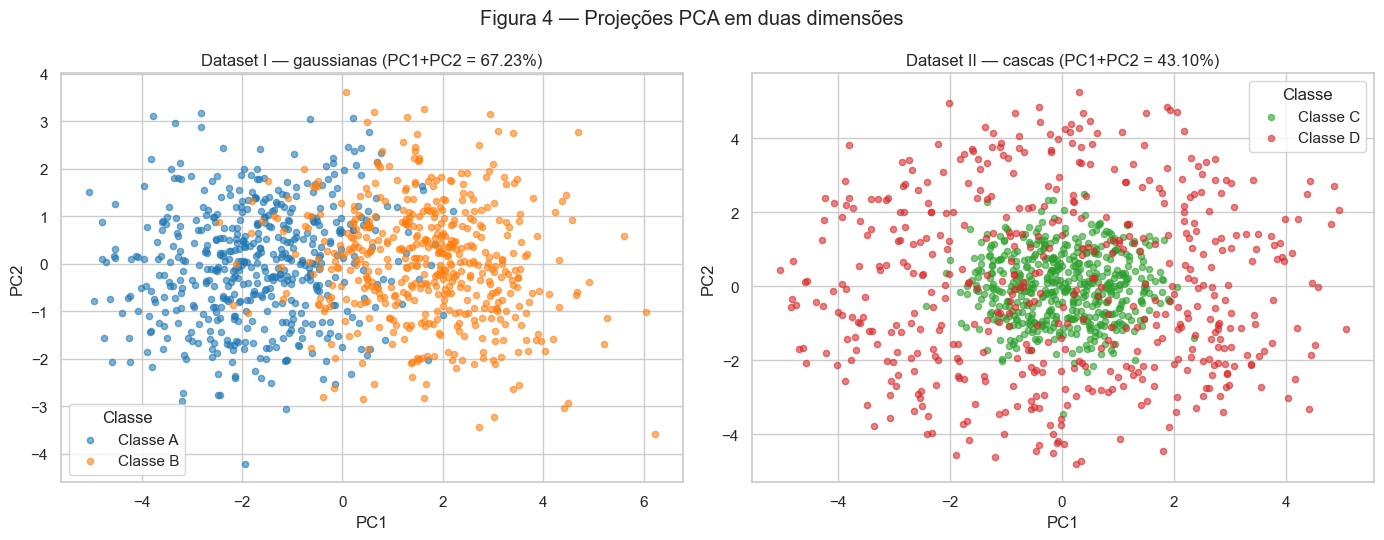

A variância explicada por PC1+PC2 é **67.23%** no Dataset I e **43.10%** no Dataset II. No Dataset I, a projeção preserva melhor a informação relevante para classificação, pois o deslocamento entre médias é uma direção linear de alta variância. No Dataset II, a informação está no raio em 5D e não em uma direção linear específica.

In [9]:
pca_gauss = PCA(n_components=2).fit(X_gauss)
pca_shell = PCA(n_components=2).fit(X_shell)
Z_gauss = pca_gauss.transform(X_gauss)
Z_shell = pca_shell.transform(X_shell)
ev_gauss = pca_gauss.explained_variance_ratio_.sum()
ev_shell = pca_shell.explained_variance_ratio_.sum()

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
for label, color in zip(["A", "B"], [colors[0], colors[1]]):
    mask = y_gauss == label
    axes[0].scatter(Z_gauss[mask, 0], Z_gauss[mask, 1], s=20,
                    alpha=0.58, color=color, label=f"Classe {label}")
for label, color in zip(["C", "D"], [colors[2], colors[3]]):
    mask = y_shell == label
    axes[1].scatter(Z_shell[mask, 0], Z_shell[mask, 1], s=20,
                    alpha=0.58, color=color, label=f"Classe {label}")

axes[0].set(title=f"Dataset I — gaussianas (PC1+PC2 = {ev_gauss:.2%})",
            xlabel="PC1", ylabel="PC2")
axes[1].set(title=f"Dataset II — cascas (PC1+PC2 = {ev_shell:.2%})",
            xlabel="PC1", ylabel="PC2")
for ax in axes:
    ax.legend(title="Classe")
fig.suptitle("Figura 4 — Projeções PCA em duas dimensões")
fig.tight_layout()
plt.show()

display(Markdown(
    f"A variância explicada por PC1+PC2 é **{ev_gauss:.2%}** no Dataset I "
    f"e **{ev_shell:.2%}** no Dataset II. No Dataset I, a projeção preserva melhor "
    f"a informação relevante para classificação, pois o deslocamento entre médias "
    f"é uma direção linear de alta variância. No Dataset II, a informação está no raio "
    f"em 5D e não em uma direção linear específica."
))

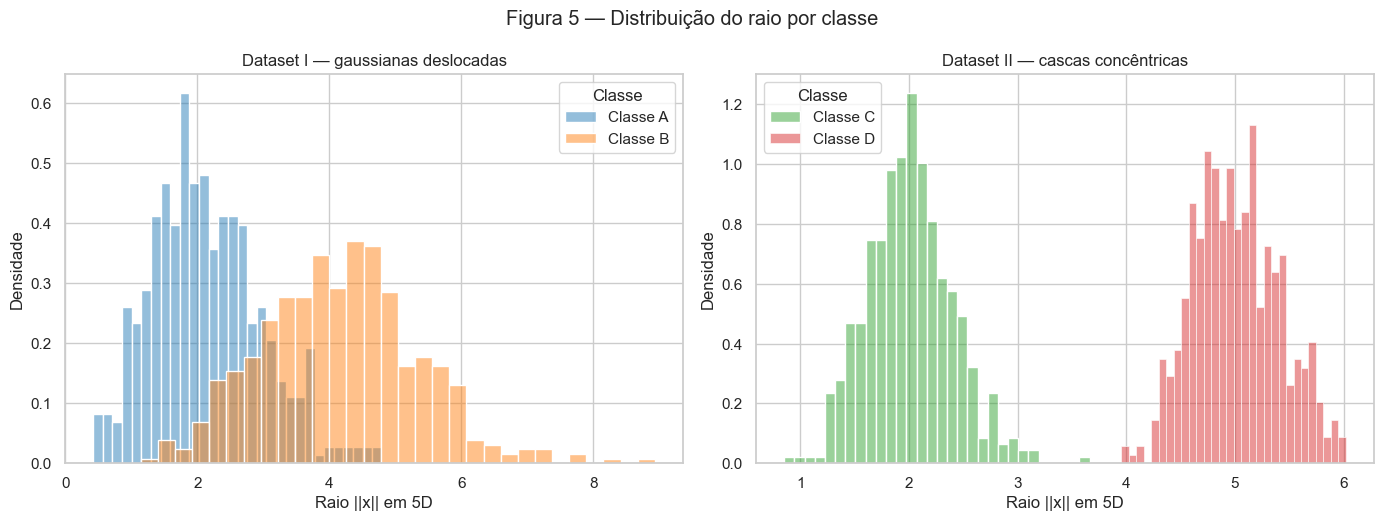

A distância empírica entre os centros é **3.4053** no Dataset I e **0.2347** no Dataset II.

In [10]:
center_distance_gauss = np.linalg.norm(XA.mean(axis=0) - XB.mean(axis=0))
center_distance_shell = np.linalg.norm(XC.mean(axis=0) - XD.mean(axis=0))

radius_A, radius_B = np.linalg.norm(XA, axis=1), np.linalg.norm(XB, axis=1)
radius_C, radius_D = np.linalg.norm(XC, axis=1), np.linalg.norm(XD, axis=1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.3))
sns.histplot(radius_A, bins=30, stat="density", alpha=0.48,
             label="Classe A", color=colors[0], ax=axes[0])
sns.histplot(radius_B, bins=30, stat="density", alpha=0.48,
             label="Classe B", color=colors[1], ax=axes[0])
sns.histplot(radius_C, bins=30, stat="density", alpha=0.48,
             label="Classe C", color=colors[2], ax=axes[1])
sns.histplot(radius_D, bins=30, stat="density", alpha=0.48,
             label="Classe D", color=colors[3], ax=axes[1])
axes[0].set(title="Dataset I — gaussianas deslocadas", xlabel="Raio ||x|| em 5D",
            ylabel="Densidade")
axes[1].set(title="Dataset II — cascas concêntricas", xlabel="Raio ||x|| em 5D",
            ylabel="Densidade")
for ax in axes:
    ax.legend(title="Classe")
fig.suptitle("Figura 5 — Distribuição do raio por classe")
fig.tight_layout()
plt.show()

display(Markdown(
    f"A distância empírica entre os centros é **{center_distance_gauss:.4f}** "
    f"no Dataset I e **{center_distance_shell:.4f}** no Dataset II."
))

## D — Análise

1. No Dataset II, os centros praticamente coincidem, mas os raios ocupam intervalos bem diferentes. Portanto, a classe não depende do lado de um hiperplano em que o ponto está; depende da sua distância à origem. Um hiperplano pode cortar uma casca, mas não envolver o núcleo em todas as direções.

2. Coletar mais dados apenas preenche melhor todas as direções das duas cascas. Como as classes são invariantes à direção e diferem radialmente, não existe vetor $w$ e limiar $b$ tais que o sinal de $w^Tx+b$ separe interior e exterior em toda a esfera. A fronteira apropriada é aproximadamente esférica, portanto não linear.

3. Uma projeção PCA 2D aparentemente misturada **não prova** inseparabilidade no espaço original: PCA é linear, não usa os rótulos e descarta três dimensões. Isso aparece aqui porque o Dataset II parece misturado na projeção, apesar de seus histogramas de raio em 5D serem quase disjuntos. Uma função separadora simples é

$$
f(x)=\sum_{i=1}^{5}x_i^2-c,
$$

com $c$ entre $2^2$ e $5^2$ (por exemplo, $c=12{,}25$, equivalente a um raio-limite de 3,5). Classificamos como D quando $f(x)>0$ e como C caso contrário.

In [11]:
def separate_shells(X, threshold_radius=3.5):
    # 0 para núcleo C e 1 para casca D.
    return (np.sum(X**2, axis=1) > threshold_radius**2).astype(int)

shell_truth = np.r_[np.zeros(500, dtype=int), np.ones(500, dtype=int)]
shell_accuracy = np.mean(separate_shells(X_shell) == shell_truth)
display(Markdown(f"Com limiar radial 3,5, essa função separa **{shell_accuracy:.2%}** das amostras geradas."))

Com limiar radial 3,5, essa função separa **99.90%** das amostras geradas.

# Exercício 3 — Preparando dados reais para uma rede neural

## A — Conhecendo os dados

O arquivo `train.csv` vem da competição **Spaceship Titanic** do Kaggle. O objetivo é prever `Transported`: se cada passageiro foi transportado para outra dimensão após a colisão com a anomalia. O arquivo é carregado localmente para que o relatório seja reproduzível.

In [12]:
data_path = Path("train.csv")
if not data_path.exists():
    raise FileNotFoundError(
        "Coloque o train.csv da competição Spaceship Titanic na mesma pasta do notebook."
    )

df = pd.read_csv(data_path)
display(df.head())
print("Dimensão original:", df.shape)

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0000,False,0.0000,0.0000,0.0000,0.0000,0.0000,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0000,False,109.0000,9.0000,25.0000,549.0000,44.0000,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0000,True,43.0000,"3,576.0000",0.0000,"6,715.0000",49.0000,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0000,False,0.0000,"1,283.0000",371.0000,"3,329.0000",193.0000,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0000,False,303.0000,70.0000,151.0000,565.0000,2.0000,Willy Santantines,True


Dimensão original: (8693, 14)


In [13]:
balance = df["Transported"].value_counts().rename_axis("Transported").to_frame("Contagem")
balance["Percentual"] = 100 * balance["Contagem"] / len(df)
display(balance.style.format({"Percentual": "{:.2f}%"}))
positive_share = df["Transported"].mean()
display(Markdown(
    f"A classe positiva (`Transported=True`) corresponde a **{positive_share:.2%}** "
    f"dos passageiros; as classes são praticamente balanceadas."
))

,Contagem,Percentual
Transported,,
True,4378,50.36%
False,4315,49.64%


A classe positiva (`Transported=True`) corresponde a **50.36%** dos passageiros; as classes são praticamente balanceadas.

As variáveis são separadas pelo significado:

- **Numéricas:** `Age`, `RoomService`, `FoodCourt`, `ShoppingMall`, `Spa`, `VRDeck`.
- **Categóricas/binárias:** `HomePlanet`, `CryoSleep`, `Cabin`, `Destination`, `VIP`, `Name` e `PassengerId`. Embora os três últimos identificadores sejam armazenados como texto, `PassengerId`, `Name` e `Cabin` serão descartados porque têm cardinalidade alta e exigiriam engenharia específica. `Transported` é o alvo, não uma feature.

In [14]:
missing = df.isna().sum().to_frame("Ausentes")
missing["Percentual"] = 100 * missing["Ausentes"] / len(df)
display(missing.sort_values("Ausentes", ascending=False)
        .style.format({"Percentual": "{:.2f}%"}))

,Ausentes,Percentual
CryoSleep,217,2.50%
ShoppingMall,208,2.39%
VIP,203,2.34%
HomePlanet,201,2.31%
Name,200,2.30%
Cabin,199,2.29%
VRDeck,188,2.16%
FoodCourt,183,2.11%
Spa,183,2.11%
Destination,182,2.09%


In [15]:
spend_cols = ["RoomService", "FoodCourt", "ShoppingMall", "Spa", "VRDeck"]
spend_stats_full = df[spend_cols].agg(["mean", "median", "max"]).T
spend_stats_full.columns = ["Média", "Mediana", "Máximo"]
display(spend_stats_full.style.format("{:,.2f}"))

,Média,Mediana,Máximo
RoomService,224.69,0.00,"14,327.00"
FoodCourt,458.08,0.00,"29,813.00"
ShoppingMall,173.73,0.00,"23,492.00"
Spa,311.14,0.00,"22,408.00"
VRDeck,304.85,0.00,"24,133.00"


Em todas as variáveis de gasto, a média é muito maior que a mediana (frequentemente zero), enquanto o máximo fica muito distante de ambas. Isso revela distribuições fortemente assimétricas à direita e com caudas pesadas: a maioria dos passageiros gasta pouco ou nada, e poucos passageiros têm valores extremos.

## B — Divisão antes das transformações

A divisão 80/20 é estratificada pelo alvo e usa semente fixa. Ela ocorre antes de imputação, criação de categorias e escala porque mediana, categorias observadas, média e desvio-padrão devem ser estimados somente com o treino. Usar o conjunto completo revelaria ao pipeline informação do teste, causando *data leakage* e uma avaliação excessivamente otimista.

In [16]:
X_raw = df.drop(columns="Transported")
y = df["Transported"].astype(int)
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y, test_size=0.20, stratify=y, random_state=42
)
print("Treino:", X_train_raw.shape, "Teste:", X_test_raw.shape)
print("Positivos — treino:", f"{y_train.mean():.2%}", "teste:", f"{y_test.mean():.2%}")

# Números pedidos no resumo: FoodCourt no treino, antes de qualquer transformação.
foodcourt_train_mean = X_train_raw["FoodCourt"].mean()
foodcourt_train_median = X_train_raw["FoodCourt"].median()
display(Markdown(
    f"No treino, antes das transformações, `FoodCourt` tem média "
    f"**{foodcourt_train_mean:,.2f}** e mediana **{foodcourt_train_median:,.2f}**."
))

Treino: (6954, 13) Teste: (1739, 13)
Positivos — treino: 50.36% teste: 50.37%


No treino, antes das transformações, `FoodCourt` tem média **452.61** e mediana **0.00**.

## C — Pré-processamento

Estratégia:

- variáveis numéricas recebem a mediana do **treino**, robusta às caudas pesadas;
- variáveis categóricas recebem a moda do **treino**;
- o one-hot usa `handle_unknown='ignore'`, então uma categoria inédita no teste produz zeros nas colunas conhecidas em vez de erro;
- após imputar os cinco gastos, `TotalSpend` é criado como sua soma;
- aplica-se $\log(1+x)$ aos cinco gastos e a `TotalSpend`, comprimindo valores extremos;
- as sete variáveis numéricas são padronizadas com média 0 e desvio-padrão 1 usando somente o treino. A padronização mantém a maior parte dos valores perto da região não saturada da `tanh`.

In [17]:
numeric_base = ["Age"] + spend_cols
categorical_cols = ["HomePlanet", "CryoSleep", "Destination", "VIP"]

# 1) Imputação — ajuste apenas no treino.
num_imputer = SimpleImputer(strategy="median")
cat_imputer = SimpleImputer(strategy="most_frequent")

train_num = pd.DataFrame(
    num_imputer.fit_transform(X_train_raw[numeric_base]),
    columns=numeric_base, index=X_train_raw.index
)
test_num = pd.DataFrame(
    num_imputer.transform(X_test_raw[numeric_base]),
    columns=numeric_base, index=X_test_raw.index
)
train_cat = pd.DataFrame(
    cat_imputer.fit_transform(X_train_raw[categorical_cols]),
    columns=categorical_cols, index=X_train_raw.index
)
test_cat = pd.DataFrame(
    cat_imputer.transform(X_test_raw[categorical_cols]),
    columns=categorical_cols, index=X_test_raw.index
)

# 2) Engenharia: soma após imputação para não propagar NaN.
for frame in (train_num, test_num):
    frame["TotalSpend"] = frame[spend_cols].sum(axis=1)

# 3) Log1p nos gastos e no gasto total.
log_cols = spend_cols + ["TotalSpend"]
train_num[log_cols] = np.log1p(train_num[log_cols])
test_num[log_cols] = np.log1p(test_num[log_cols])

# 4) Padronização numérica — fit só no treino.
numeric_final = numeric_base + ["TotalSpend"]
scaler = StandardScaler()
train_num_scaled = scaler.fit_transform(train_num[numeric_final])
test_num_scaled = scaler.transform(test_num[numeric_final])

# 5) One-hot — compatível com versões novas e antigas do scikit-learn.
try:
    encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    encoder = OneHotEncoder(handle_unknown="ignore", sparse=False)
train_cat_encoded = encoder.fit_transform(train_cat)
test_cat_encoded = encoder.transform(test_cat)

feature_names = numeric_final + list(encoder.get_feature_names_out(categorical_cols))
X_train = pd.DataFrame(
    np.hstack([train_num_scaled, train_cat_encoded]),
    columns=feature_names, index=X_train_raw.index
)
X_test = pd.DataFrame(
    np.hstack([test_num_scaled, test_cat_encoded]),
    columns=feature_names, index=X_test_raw.index
)

print("Features finais:")
print(feature_names)

Features finais:
['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck', 'TotalSpend', 'HomePlanet_Earth', 'HomePlanet_Europa', 'HomePlanet_Mars', 'CryoSleep_False', 'CryoSleep_True', 'Destination_55 Cancri e', 'Destination_PSO J318.5-22', 'Destination_TRAPPIST-1e', 'VIP_False', 'VIP_True']


## D — Verificação e visualização

A Figura 6 usa exatamente os registros do treino. À esquerda está `FoodCourt` antes do pré-processamento (ignorando ausentes apenas para desenhar); à direita está a mesma feature após imputação, `log1p` e padronização.

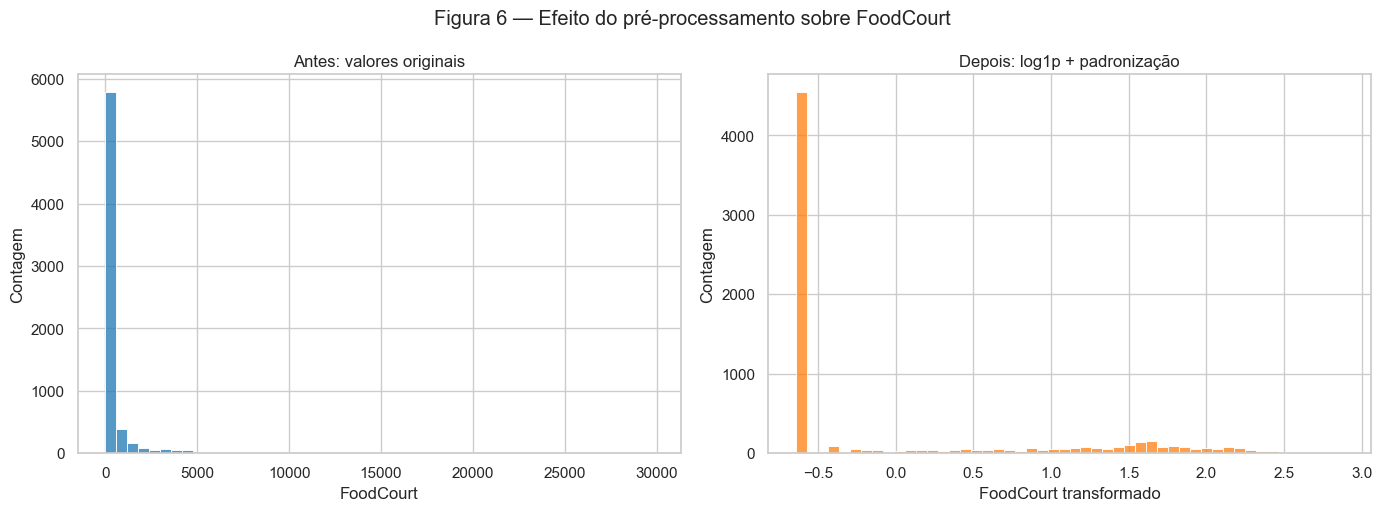

In [18]:
foodcourt_idx = numeric_final.index("FoodCourt")
fig, axes = plt.subplots(1, 2, figsize=(14, 5.2))
sns.histplot(X_train_raw["FoodCourt"].dropna(), bins=50, color=colors[0], ax=axes[0])
sns.histplot(train_num_scaled[:, foodcourt_idx], bins=50, color=colors[1], ax=axes[1])
axes[0].set(title="Antes: valores originais", xlabel="FoodCourt", ylabel="Contagem")
axes[1].set(title="Depois: log1p + padronização", xlabel="FoodCourt transformado", ylabel="Contagem")
fig.suptitle("Figura 6 — Efeito do pré-processamento sobre FoodCourt")
fig.tight_layout()
plt.show()

In [19]:
train_nan = int(X_train.isna().sum().sum())
test_nan = int(X_test.isna().sum().sum())
train_min, train_max = X_train.to_numpy().min(), X_train.to_numpy().max()
test_min, test_max = X_test.to_numpy().min(), X_test.to_numpy().max()

checks = pd.DataFrame({
    "Conjunto": ["Treino", "Teste"],
    "Shape": [str(X_train.shape), str(X_test.shape)],
    "NaN restantes": [train_nan, test_nan],
    "Mínimo": [train_min, test_min],
    "Máximo": [train_max, test_max],
})
display(checks.style.format({"Mínimo": "{:.4f}", "Máximo": "{:.4f}"}))

display(Markdown(
    f"As matrizes finais têm **zero NaN**. O treino tem shape **{X_train.shape}** "
    f"e varia de **{train_min:.4f}** a **{train_max:.4f}**; o teste tem shape "
    f"**{X_test.shape}** e varia de **{test_min:.4f}** a **{test_max:.4f}**. "
    f"As variáveis contínuas foram centradas e padronizadas; as one-hot ficam em 0 ou 1. "
    f"A padronização não limita rigidamente o intervalo, mas concentra a maioria dos valores "
    f"perto de zero, uma escala adequada para `tanh`."
))

,Conjunto,Shape,NaN restantes,Mínimo,Máximo
0,Treino,"(6954, 17)",0,-1.9961,3.5080
1,Teste,"(1739, 17)",0,-1.9961,3.3687


As matrizes finais têm **zero NaN**. O treino tem shape **(6954, 17)** e varia de **-1.9961** a **3.5080**; o teste tem shape **(1739, 17)** e varia de **-1.9961** a **3.3687**. As variáveis contínuas foram centradas e padronizadas; as one-hot ficam em 0 ou 1. A padronização não limita rigidamente o intervalo, mas concentra a maioria dos valores perto de zero, uma escala adequada para `tanh`.

### Reflexão

A combinação de `log1p` com padronização provavelmente tem o maior efeito no treinamento. Sem o log, os poucos gastos extremos dominariam a média, a variância e os gradientes; depois da escala, a maioria dos exemplos poderia ficar comprimida numa região pouco informativa enquanto alguns outliers levariam ativações `tanh` à saturação. O log reduz a assimetria antes de o `StandardScaler` ser ajustado, deixando diferenças entre gastos baixos mais visíveis e tornando a otimização numericamente mais estável. A divisão antes de qualquer ajuste é igualmente indispensável para que essa conclusão e uma futura avaliação sejam válidas.

# Resumo dos resultados

A tabela abaixo reúne os números já calculados nas seções anteriores, conforme solicitado.

In [20]:
summary = pd.DataFrame([
    (1, "Taxa de mistura em s = 0.5", f"{mixing[0.5]:.4f} ({mixing[0.5]:.2%})"),
    (2, "Taxa de mistura em s = 1.0", f"{mixing[1.0]:.4f} ({mixing[1.0]:.2%})"),
    (3, "Taxa de mistura em s = 2.0", f"{mixing[2.0]:.4f} ({mixing[2.0]:.2%})"),
    (4, "Taxa de mistura em s = 4.0", f"{mixing[4.0]:.4f} ({mixing[4.0]:.2%})"),
    (5, "Menor r_ij em s = 1.0 e par", f"{smallest_ratio:.4f}, par {smallest_pair}"),
    (6, "Distância entre centros — Dataset I", f"{center_distance_gauss:.4f}"),
    (7, "Distância entre centros — Dataset II", f"{center_distance_shell:.4f}"),
    (8, "Variância explicada PC1 + PC2 — Dataset I", f"{ev_gauss:.4f} ({ev_gauss:.2%})"),
    (9, "Variância explicada PC1 + PC2 — Dataset II", f"{ev_shell:.4f} ({ev_shell:.2%})"),
    (10, "Participação da classe positiva em Transported", f"{positive_share:.4f} ({positive_share:.2%})"),
    (11, "Média e mediana de FoodCourt no treino, antes", f"{foodcourt_train_mean:,.2f}; {foodcourt_train_median:,.2f}"),
    (12, "Shape final da matriz de treino", str(X_train.shape)),
    (13, "Mínimo e máximo após escala — treino; teste",
     f"treino [{train_min:.4f}, {train_max:.4f}]; teste [{test_min:.4f}, {test_max:.4f}]"),
], columns=["#", "Item", "Valor"])
display(summary.style.hide(axis="index"))

#,Item,Valor
1,Taxa de mistura em s = 0.5,0.0000 (0.00%)
2,Taxa de mistura em s = 1.0,0.0675 (6.75%)
3,Taxa de mistura em s = 2.0,0.2250 (22.50%)
4,Taxa de mistura em s = 4.0,0.4175 (41.75%)
5,Menor r_ij em s = 1.0 e par,"1.3258, par (0, 1)"
6,Distância entre centros — Dataset I,3.4053
7,Distância entre centros — Dataset II,0.2347
8,Variância explicada PC1 + PC2 — Dataset I,0.6723 (67.23%)
9,Variância explicada PC1 + PC2 — Dataset II,0.4310 (43.10%)
10,Participação da classe positiva em Transported,0.5036 (50.36%)
